# HyperBench Tutorial 02: Loading and Visualization

This notebook focuses on bringing hyperspectral data into HyperBench and inspecting it carefully before any degradation or model evaluation begins.

The notation used throughout the tutorial series is:

- ground-truth hyperspectral image (GT HSI / HR HSI): `(H, W, C)`
- low-resolution hyperspectral image (LR HSI): `(H/r, W/r, C)`
- high-resolution multispectral image (HR MSI): `(H, W, c)`
- spectral response function (SRF): `(c, C)`
- point spread function (PSF): `(k, k)`

This notebook covers:

- loading a MATLAB scene with `load_hsi`
- understanding the expected `(H, W, C)` layout
- checking the scene numerically with `print_data_stats`
- viewing an RGB composite with `visualize_hsi`
- inspecting individual hyperspectral channels with `visualize_band`
- comparing spectral signatures with `plot_spectra`

## Related documentation

- `docs/index.md`
- `docs/io.md`
- `docs/visualization.md`
- `docs/core-concepts.md`

## Imports

In [1]:
from pathlib import Path

import numpy as np

from hyperbench import (
    __version__,
    load_hsi,
    normalize_image,
    plot_spectra,
    print_data_stats,
    visualize_band,
    visualize_hsi,
)

print("HyperBench version:", __version__)

HyperBench version: 0.1.0


## Scene configuration

Set the scene path and the key inside the MATLAB file.

In [2]:
SCENE_PATH = Path("../data/DC_data.mat")
SCENE_KEY = "dc"

print("Scene path:", SCENE_PATH)
print("Scene key:", SCENE_KEY)

Scene path: ../data/DC_data.mat
Scene key: dc


## Load the scene

HyperBench expects hyperspectral scenes in channel-last format:

- `H`: height
- `W`: width
- `C`: hyperspectral channels

`load_hsi` returns a NumPy array that can be passed directly into the rest of the framework.

In [3]:
scene = load_hsi(SCENE_PATH, key=SCENE_KEY)
print("Loaded type:", type(scene))
print("Loaded shape (H, W, C):", scene.shape)

Loaded type: <class 'numpy.ndarray'>
Loaded shape (H, W, C): (1280, 307, 191)


## Inspect the raw scene numerically

The raw scene may not yet be normalized, so it is useful to check the value range before doing anything else.

In [4]:
print_data_stats(scene, name="Raw scene")

Raw scene type: <class 'numpy.ndarray'>
Raw scene dtype: float32
Raw scene shape (H, W, B): (1280, 307, 191)
Raw scene min: -32728.0
Raw scene max: 32701.0
Raw scene mean: 2009.333740234375
Raw scene std: 2266.9697265625


## Normalize the scene

For visualization and later evaluation, it is convenient to work with a normalized representation.

The normalized result is still the same hyperspectral cube, but scaled into a consistent range.

In [5]:
gt_hsi = normalize_image(scene)
print_data_stats(gt_hsi, name="Normalized scene")
print("Normalized shape (H, W, C):", gt_hsi.shape)

Normalized scene type: <class 'numpy.ndarray'>
Normalized scene dtype: float32
Normalized scene shape (H, W, B): (1280, 307, 191)
Normalized scene min: 0.0
Normalized scene max: 1.0
Normalized scene mean: 0.2233569175004959
Normalized scene std: 0.24737973511219025
Normalized shape (H, W, C): (1280, 307, 191)


## Select RGB channels

A hyperspectral cube contains many channels, so an RGB image must be formed by choosing three of them.

This notebook uses three representative channels spread across the spectral dimension.

In [6]:
rgb_channels = (50, 35, 15)

print("RGB channel indices:", rgb_channels)

RGB channel indices: (50, 35, 15)


## Visualize the scene as an RGB composite

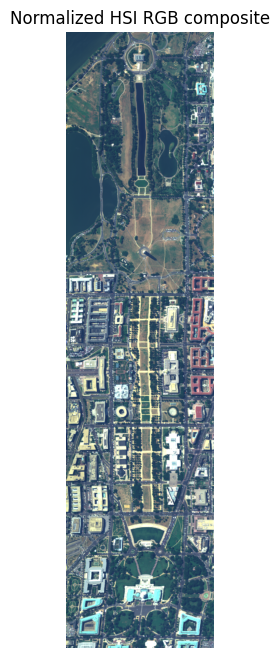

In [7]:
visualize_hsi(gt_hsi, bands=rgb_channels, title="Normalized HSI RGB composite")

## Inspect individual hyperspectral channels

A single channel often reveals spatial structure that is not obvious in the RGB composite.

Below are three channels sampled from different parts of the spectrum.

In [8]:
num_channels = gt_hsi.shape[2]

channel_indices = [
    min(num_channels - 1, int(num_channels * 0.2)),
    min(num_channels - 1, int(num_channels * 0.5)),
    min(num_channels - 1, int(num_channels * 0.8)),
]

print("Channel indices selected for inspection:", channel_indices)

Channel indices selected for inspection: [38, 95, 152]


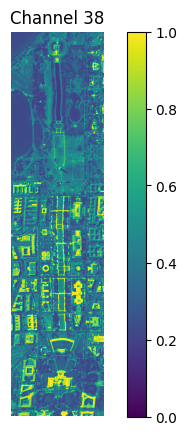

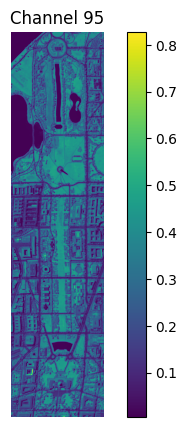

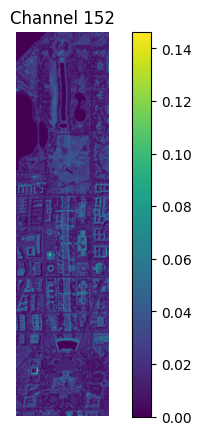

In [9]:
for channel_idx in channel_indices:
    visualize_band(
        gt_hsi,
        band_idx=channel_idx,
        title=f"Channel {channel_idx}",
    )

## Compare spectral signatures at a few pixels

Spatial inspection alone is not enough for hyperspectral data. The spectral dimension is equally important.

The plots below compare the spectra at a small set of representative pixels.

In [10]:
height, width, _ = gt_hsi.shape

sample_pixels = [
    (int(width * 0.25), int(height * 0.25)),
    (int(width * 0.50), int(height * 0.50)),
    (int(width * 0.75), int(height * 0.75)),
]

print("Sample pixels (x, y):", sample_pixels)

Sample pixels (x, y): [(76, 320), (153, 640), (230, 960)]


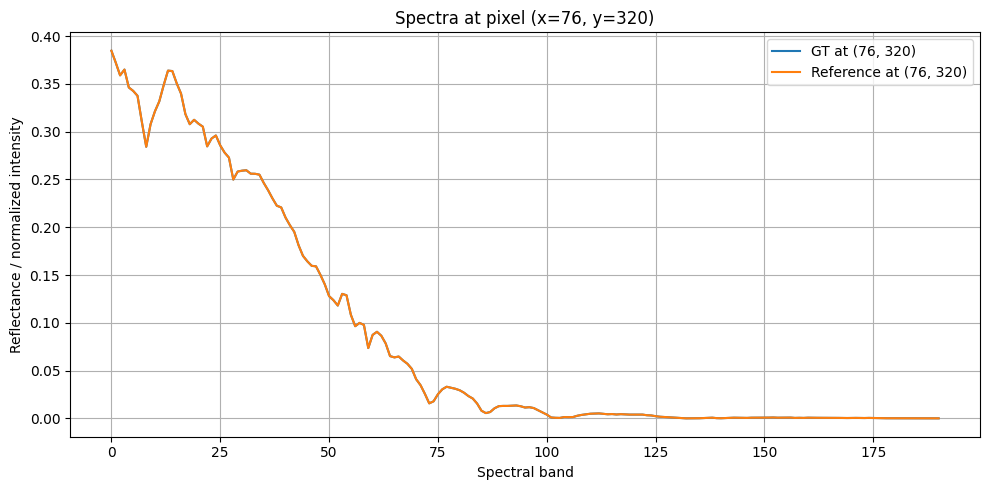

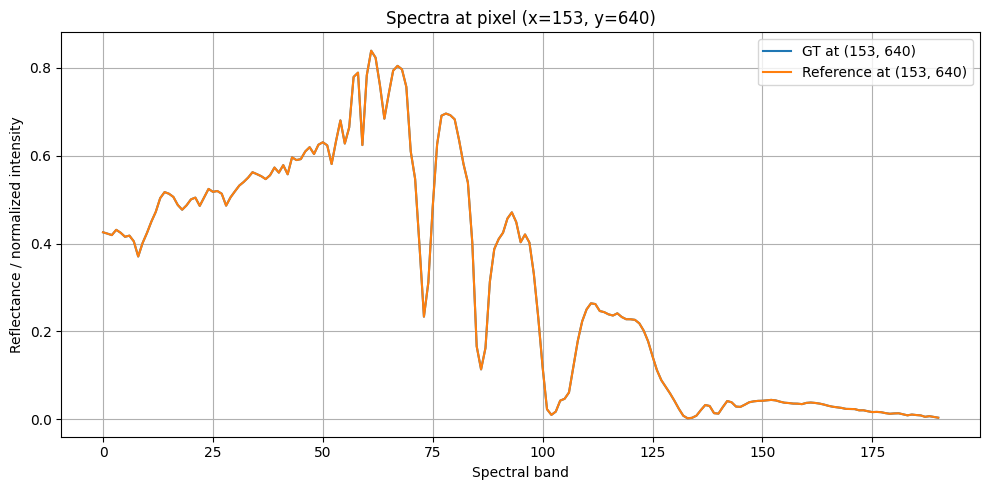

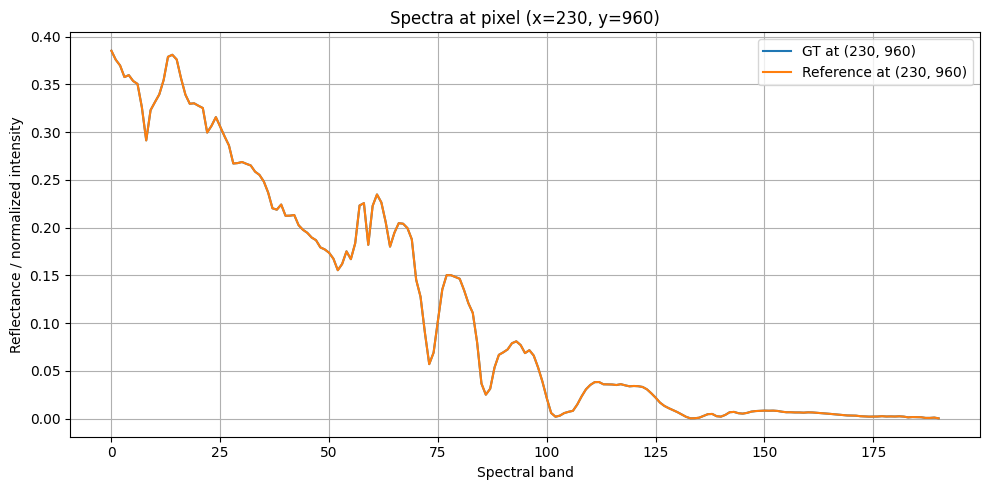

In [11]:
for x, y in sample_pixels:
    plot_spectra(
        ground_truth_hsi=gt_hsi,
        predicted_hsi=gt_hsi,
        x=x,
        y=y,
        gt_label=f"GT at ({x}, {y})",
        pred_label=f"Reference at ({x}, {y})",
    )

## A note on shape conventions

HyperBench uses `(H, W, C)` throughout the NumPy-facing API.

This is important because many external libraries and models use other conventions such as:

- `(C, H, W)`
- `(1, H, W, C)`
- `(1, C, H, W)`

The conversion utilities documented elsewhere handle those framework-specific formats, but the scene loaded here remains in HyperBench's native layout.

## Summary

This notebook covered the first stage of any HyperBench workflow:

- loading a scene from a MATLAB file
- confirming the expected shape
- checking data statistics
- visualizing the scene as RGB
- inspecting individual channels
- examining spectral signatures at selected pixels

These checks are often enough to catch data issues before moving on to degradations or model evaluation.